In [ ]:
from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession

# Create a local Spark configuration and context
spark = SparkSession.builder \
    .appName("Read CSV Example") \
    .getOrCreate()

# Verify that SparkContext started
print("✅ SparkContext initialized:", spark)

✅ SparkContext initialized: <pyspark.sql.session.SparkSession object at 0x12f747230>


In [ ]:
df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("delimiter", "\t") \
    .load('data/features_array.csv')

df.printSchema()

root
 |-- Polygon_ID: integer (nullable = true)
 |-- acq_date: date (nullable = true)
 |-- frp: string (nullable = true)
 |-- acq_time: string (nullable = true)
 |-- Neighbour: double (nullable = true)
 |-- Neighbour_frp: string (nullable = true)
 |-- Neighbour_acq_time: string (nullable = true)
 |-- ELEV_max: double (nullable = true)
 |-- ELEV_min: double (nullable = true)
 |-- ELEV_median: double (nullable = true)
 |-- ELEV_sum: double (nullable = true)
 |-- ELEV_mode: double (nullable = true)
 |-- ELEV_count: double (nullable = true)
 |-- ELEV_mean: double (nullable = true)
 |-- SLP_max: double (nullable = true)
 |-- SLP_min: double (nullable = true)
 |-- SLP_median: double (nullable = true)
 |-- SLP_sum: double (nullable = true)
 |-- SLP_mode: double (nullable = true)
 |-- SLP_count: double (nullable = true)
 |-- SLP_mean: double (nullable = true)
 |-- EVT_max: double (nullable = true)
 |-- EVT_min: double (nullable = true)
 |-- EVT_median: double (nullable = true)
 |-- EVT_sum: do

In [ ]:
from pyspark.sql.functions import col, unix_timestamp, lit
from pyspark.sql.types import DateType, DoubleType

remove_cols = ['Polygon_ID','acq_time','Neighbour','Neighbour_acq_time','Shape','Neighbour_Shape','TEMP_ave']

df = df.drop(*remove_cols)
df = df.withColumn("acq_date", unix_timestamp(col("acq_date")).cast(DoubleType()))


In [ ]:
df = df.filter(~df.frp.contains(","))
df = df.withColumn("frp", col("frp").cast(DoubleType()))

In [ ]:
from pyspark.sql import functions as F

majority_class_percent = 0.9229
no_spread_weight = 1 / majority_class_percent
spread_weight = 1 / (1 - majority_class_percent)

df = df.withColumn(
    "Neighbour_frp",
    F.when(F.col("Neighbour_frp").isNull(), 0.0).otherwise(1.0)
)

df = df.withColumn(
    "weight",
    F.when(F.col("Neighbour_frp") == 0.0, no_spread_weight).otherwise(spread_weight)
)

In [ ]:
from pyspark.ml.feature import Imputer

input_cols = [c for c in df.columns if c != "Neighbour_frp"]

imputer = Imputer(
    inputCols=input_cols,
    outputCols=input_cols
).setStrategy("mean")

model = imputer.fit(df)
df = model.transform(df)

In [ ]:
from pyspark.ml.feature import VectorAssembler

input_cols = [c for c in df.columns if (c != "Neighbour_frp") and (c != "weight")]

assembler = VectorAssembler(inputCols= input_cols, outputCol="features")
assembled = assembler.transform(df)
assembled = assembled.withColumn('label',col('Neighbour_frp'))


In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.linalg import Vectors

df2 = assembled.select('label','features','weight')

# Split data
#Training data is 70% of total entries, 30% is saved for testing
train_data, test_data = df2.randomSplit([0.7, 0.3])

# Train model
'''
makes a decision tree classifier that uses the column "label" as the label to classify, the
column "features" as the features to form the decision tree, and gini as the impurity metric.
the tree can be no deeper than 5 decisions
'''

dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", weightCol ="weight", impurity="gini", maxDepth=6)
model = dt.fit(train_data)

# Predict
'''
runs the model on the test data from earlier, adding a predictions column with values 1.0 or 0.0
depending on the prediction
'''
predictions = model.transform(test_data)

# Evaluate
'''
compares the predictions of the model on the test data to the labels of the predictions
'''
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Test Accuracy = {accuracy:.4f}")
evaluator2 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")
f1 = evaluator2.evaluate(predictions)
print(f"Test F1 Score = {f1:.4f}")

# Show tree
print(model.toDebugString)

25/12/03 10:43:48 WARN MemoryStore: Not enough space to cache rdd_282_1 in memory! (computed 5.5 MiB so far)
25/12/03 10:43:48 WARN BlockManager: Persisting block rdd_282_1 to disk instead.
25/12/03 10:43:48 WARN MemoryStore: Not enough space to cache rdd_282_5 in memory! (computed 18.7 MiB so far)
25/12/03 10:43:48 WARN BlockManager: Persisting block rdd_282_5 to disk instead.
25/12/03 10:43:48 WARN MemoryStore: Not enough space to cache rdd_282_0 in memory! (computed 28.3 MiB so far)
25/12/03 10:43:48 WARN BlockManager: Persisting block rdd_282_0 to disk instead.
25/12/03 10:43:53 WARN MemoryStore: Not enough space to cache rdd_282_8 in memory! (computed 28.3 MiB so far)
25/12/03 10:43:53 WARN BlockManager: Persisting block rdd_282_8 to disk instead.
25/12/03 10:43:53 WARN MemoryStore: Not enough space to cache rdd_282_12 in memory! (computed 12.5 MiB so far)
25/12/03 10:43:53 WARN BlockManager: Persisting block rdd_282_12 to disk instead.
25/12/03 10:43:53 WARN MemoryStore: Not enou

Test Accuracy = 0.7228


Test F1 Score = 0.7866
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_4c7e53152394, depth=6, numNodes=93, numClasses=2, numFeatures=140
  If (feature 130 <= -891926.242898011)
   If (feature 129 <= 21.006431)
    If (feature 2 <= 1780.5)
     If (feature 91 <= 18584.5)
      If (feature 122 <= 3504.0522499999997)
       If (feature 131 <= 1273567.92060716)
        Predict: 1.0
       Else (feature 131 > 1273567.92060716)
        Predict: 0.0
      Else (feature 122 > 3504.0522499999997)
       If (feature 74 <= 33.5)
        Predict: 0.0
       Else (feature 74 > 33.5)
        Predict: 1.0
     Else (feature 91 > 18584.5)
      Predict: 0.0
    Else (feature 2 > 1780.5)
     If (feature 65 <= -1153488.74289801)
      If (feature 66 <= 2229442.92060716)
       If (feature 131 <= 1699942.9206071598)
        Predict: 1.0
       Else (feature 131 > 1699942.9206071598)
        Predict: 0.0
      Else (feature 66 > 2229442.92060716)
       Predict: 1.0
     Else (feature 65 > -1

In [ ]:
import re

def readable_tree(model, feature_names):
    s = model.toDebugString

    # Replace "feature N" with the name feature_names[N]
    def repl(match):
        idx = int(match.group(1))
        return f"feature '{feature_names[idx]}'"

    return re.sub(r"feature (\d+)", repl, s)

print(readable_tree(model, input_cols))

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_4c7e53152394, depth=6, numNodes=93, numClasses=2, numFeatures=140
  If (feature 'Neighbour_c_latitude' <= -891926.242898011)
   If (feature 'Neighbour_CH_mean' <= 21.006431)
    If (feature 'ELEV_max' <= 1780.5)
     If (feature 'Neighbour_EVH_sum' <= 18584.5)
      If (feature 'Neighbour_CC_mean' <= 3504.0522499999997)
       If (feature 'Neighbour_c_longitude' <= 1273567.92060716)
        Predict: 1.0
       Else (feature 'Neighbour_c_longitude' > 1273567.92060716)
        Predict: 0.0
      Else (feature 'Neighbour_CC_mean' > 3504.0522499999997)
       If (feature 'Neighbour_SLP_max' <= 33.5)
        Predict: 0.0
       Else (feature 'Neighbour_SLP_max' > 33.5)
        Predict: 1.0
     Else (feature 'Neighbour_EVH_sum' > 18584.5)
      Predict: 0.0
    Else (feature 'ELEV_max' > 1780.5)
     If (feature 'c_latitude' <= -1153488.74289801)
      If (feature 'c_longitude' <= 2229442.92060716)
       If (feature 'Neighbour_c_l

In [ ]:
evaluator2 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="f1", metricName="accuracy")
f1 = evaluator2.evaluate(predictions)
print(f"Test F1 score = {f1:.4f}")

ConnectionRefusedError: [Errno 61] Connection refused

In [ ]:
accs = []
depths = range(1,16)

for d in depths:
    total = 0
    print("Depth "+str(d)+":\n")
    for i in range(5):
        print("Beginning run "+str(i))
        train_data, test_data = df2.randomSplit([0.7, 0.3])

        dt = DecisionTreeClassifier(labelCol="label", featuresCol="features", impurity="gini", maxDepth=d)
        model = dt.fit(train_data)

        predictions = model.transform(test_data)

        evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
        total += evaluator.evaluate(predictions)
    accs.append(total / 5)
    print()

Depth 1:

Beginning run 0


Beginning run 1
Beginning run 2


Beginning run 3


Beginning run 4



Depth 2:

Beginning run 0
Beginning run 1
Beginning run 2


Beginning run 3
Beginning run 4

Depth 3:

Beginning run 0
Beginning run 1
Beginning run 2
Beginning run 3
Beginning run 4

Depth 4:

Beginning run 0
Beginning run 1
Beginning run 2
Beginning run 3
Beginning run 4

Depth 5:

Beginning run 0
Beginning run 1
Beginning run 2
Beginning run 3
Beginning run 4

Depth 6:

Beginning run 0
Beginning run 1
Beginning run 2
Beginning run 3
Beginning run 4

Depth 7:

Beginning run 0
Beginning run 1
Beginning run 2
Beginning run 3
Beginning run 4

Depth 8:

Beginning run 0
Beginning run 1
Beginning run 2
Beginning run 3
Beginning run 4

Depth 9:

Beginning run 0
Beginning run 1
Beginning run 2
Beginning run 3
Beginning run 4

Depth 10:

Beginning run 0
Beginning run 1
Beginning run 2
Beginning run 3
Beginning run 4

Depth 11:

Beginning run 0
Beginning run 1
Beginning run 2
Beginning run 3
Beginning run 4

Depth 12:

Beginning run 0
Beginning run 1
Beginning run 2
Beginning run 3
Beginning run 4

Depth 13:

Beginning run 0
Beginning run 1
Beginning r

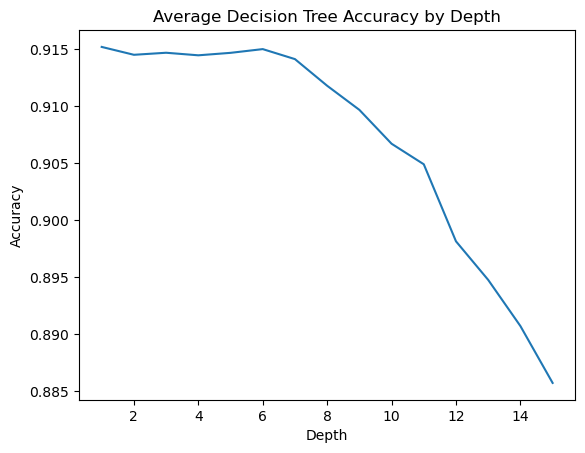

In [ ]:
from matplotlib import pyplot as plt

plt.plot(depths, accs)
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.title("Average Decision Tree Accuracy by Depth")
plt.show()

In [ ]:
import os
import findspark
findspark.init()
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MyFirstSparkApp") \
    .config("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true") \
    .config("spark.python.worker.faulthandler.enabled", "true") \
    .getOrCreate()

print("Spark version:", spark.version)



Spark version: 3.5.7


In [ ]:
csv_file_path = "data/features_array.csv"


df = spark.read.format("csv") \
    .option("header", "true") \
    .option("delimiter", "\t") \
    .option("inferSchema", "true") \
    .load(csv_file_path)

In [ ]:

df.show(5)

+-----------+---+-------------+--------+--------+-----------+--------+---------+----------+---------+-------+-------+----------+-------+--------+---------+--------+-------+-------+----------+-------+--------+---------+---------+-------+-------+----------+-------+--------+---------+----------+-------+-------+----------+---------+--------+---------+---------+-------+-------+----------+-------+--------+---------+---------+-------+-------+----------+-------+--------+---------+----------+------+------+---------+--------+-------+--------+---------+------+------+---------+-------+-------+--------+---------+-------------------+----------------+------------------+------------------+---------------------+------------------+-------------------+--------------------+-------------------+-----------------+-----------------+--------------------+-----------------+------------------+-------------------+------------------+-----------------+-----------------+--------------------+-----------------+--------

In [ ]:
from pyspark.sql.functions import col, unix_timestamp, lit
from pyspark.sql.types import DateType, DoubleType

remove_cols = ['Polygon_ID','acq_time','Neighbour','Neighbour_acq_time','Shape','Neighbour_Shape','TEMP_ave']

df = df.drop(*remove_cols)
df = df.withColumn("acq_date", unix_timestamp(col("acq_date")).cast(DoubleType()))


In [ ]:
df = df.filter(~df.frp.contains(","))
df = df.withColumn("frp", col("frp").cast(DoubleType()))

In [ ]:
df.show(5)

+-----------+---+-------------+--------+--------+-----------+--------+---------+----------+---------+-------+-------+----------+-------+--------+---------+--------+-------+-------+----------+-------+--------+---------+---------+-------+-------+----------+-------+--------+---------+----------+-------+-------+----------+---------+--------+---------+---------+-------+-------+----------+-------+--------+---------+---------+-------+-------+----------+-------+--------+---------+----------+------+------+---------+--------+-------+--------+---------+------+------+---------+-------+-------+--------+---------+-------------------+----------------+------------------+------------------+---------------------+------------------+-------------------+--------------------+-------------------+-----------------+-----------------+--------------------+-----------------+------------------+-------------------+------------------+-----------------+-----------------+--------------------+-----------------+--------

In [ ]:
df.printSchema()

root
 |-- acq_date: double (nullable = true)
 |-- frp: double (nullable = true)
 |-- Neighbour_frp: string (nullable = true)
 |-- ELEV_max: double (nullable = true)
 |-- ELEV_min: double (nullable = true)
 |-- ELEV_median: double (nullable = true)
 |-- ELEV_sum: double (nullable = true)
 |-- ELEV_mode: double (nullable = true)
 |-- ELEV_count: double (nullable = true)
 |-- ELEV_mean: double (nullable = true)
 |-- SLP_max: double (nullable = true)
 |-- SLP_min: double (nullable = true)
 |-- SLP_median: double (nullable = true)
 |-- SLP_sum: double (nullable = true)
 |-- SLP_mode: double (nullable = true)
 |-- SLP_count: double (nullable = true)
 |-- SLP_mean: double (nullable = true)
 |-- EVT_max: double (nullable = true)
 |-- EVT_min: double (nullable = true)
 |-- EVT_median: double (nullable = true)
 |-- EVT_sum: double (nullable = true)
 |-- EVT_mode: double (nullable = true)
 |-- EVT_count: double (nullable = true)
 |-- EVT_mean: double (nullable = true)
 |-- EVH_max: double (nullab

In [ ]:
import os
import findspark
findspark.init()
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MyFirstSparkApp") \
    .config("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true") \
    .config("spark.python.worker.faulthandler.enabled", "true") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 3.5.7


In [ ]:
csv_file_path = "data/features_array.csv"


df = spark.read.format("csv") \
    .option("header", "true") \
    .option("delimiter", "\t") \
    .option("inferSchema", "true") \
    .load(csv_file_path)

In [ ]:

df.show()

+----------+----------+-------+---------+---------+-------------+------------------+--------+--------+-----------+--------+---------+----------+---------+-------+-------+----------+-------+--------+---------+--------+-------+-------+----------+-------+--------+---------+---------+-------+-------+----------+-------+--------+---------+----------+-------+-------+----------+---------+--------+---------+---------+-------+-------+----------+-------+--------+---------+----------+-------+-------+----------+-------+--------+---------+----------+------+------+---------+--------+-------+--------+---------+------+------+---------+-------+-------+--------+---------+--------------------+-------------------+----------------+------------------+------------------+---------------------+------------------+-------------------+--------------------+-------------------+-----------------+-----------------+--------------------+-----------------+------------------+-------------------+------------------+--------

In [ ]:
coord_df = df.select("c_longitude","c_latitude").show()

+----------------+-------------------+
|     c_longitude|         c_latitude|
+----------------+-------------------+
|2292255.42060716|-2350676.2428980106|
|2297130.42060716|-2347301.2428980106|
|2284005.42060716|-2332301.2428980106|
|2064255.42060716|-2319926.2428980106|
|2205255.42060716|-2317676.2428980106|
|2283255.42060716|-2317301.2428980106|
|2203755.42060716|-2317301.2428980106|
|2197755.42060716|-2315801.2428980106|
|2203005.42060716|-2315051.2428980106|
|2129130.42060716|-2314676.2428980106|
|2202630.42060716|-2314301.2428980106|
|2203755.42060716|-2313551.2428980106|
|2201130.42060716|-2312801.2428980106|
|2200380.42060716|-2311676.2428980106|
|2120505.42060716|-2310176.2428980106|
|2056755.42060716|-2308676.2428980106|
|2181255.42060716|-2305676.2428980106|
|2284380.42060716|-2304926.2428980106|
|2251005.42060716|-2302301.2428980106|
|2141130.42060716|-2301551.2428980106|
+----------------+-------------------+
only showing top 20 rows



In [ ]:
from pyspark.sql.types import FloatType
from pyspark.sql.functions import col
filtered_df = df.filter(~col("frp").contains(","))
filtered_df = filtered_df.withColumn("frp", df["frp"].cast(FloatType()))
features_df = filtered_df.select("frp", "c_latitude","c_longitude")
features_df.show()

+----+-------------------+----------------+
| frp|         c_latitude|     c_longitude|
+----+-------------------+----------------+
| 3.1|-2350676.2428980106|2292255.42060716|
| 8.3|-2332301.2428980106|2284005.42060716|
| 6.6|-2317676.2428980106|2205255.42060716|
| 1.9|-2317301.2428980106|2283255.42060716|
| 1.1|-2317301.2428980106|2203755.42060716|
| 1.7|-2315801.2428980106|2197755.42060716|
| 1.6|-2315051.2428980106|2203005.42060716|
| 6.2|-2314676.2428980106|2129130.42060716|
| 2.9|-2314301.2428980106|2202630.42060716|
|16.3|-2313551.2428980106|2203755.42060716|
| 1.2|-2312801.2428980106|2201130.42060716|
| 1.6|-2311676.2428980106|2200380.42060716|
| 4.9|-2310176.2428980106|2120505.42060716|
| 0.7|-2308676.2428980106|2056755.42060716|
| 0.6|-2305676.2428980106|2181255.42060716|
| 1.8|-2304926.2428980106|2284380.42060716|
| 0.9|-2302301.2428980106|2251005.42060716|
|18.5|-2301551.2428980106|2141130.42060716|
| 2.9|-2301176.2428980106|2243130.42060716|
| 1.3|-2301176.2428980106|214188

In [ ]:
from pyspark.ml.feature import StandardScaler, VectorAssembler


frp_assembler = VectorAssembler(
    inputCols=["frp"],
    outputCol="frp_vec"
)
frp_vector = frp_assembler.transform(features_df)
scaler = StandardScaler(
    inputCol="frp_vec",
    outputCol="scaled_frp",
    withMean=True,
    withStd=True
)
scaled_model = scaler.fit(frp_vector)
scaled_data = scaled_model.transform(frp_vector)

scaled_data.show()

+----+-------------------+----------------+--------------------+--------------------+
| frp|         c_latitude|     c_longitude|             frp_vec|          scaled_frp|
+----+-------------------+----------------+--------------------+--------------------+
| 3.1|-2350676.2428980106|2292255.42060716|[3.0999999046325684]|[-0.2187618739383...|
| 8.3|-2332301.2428980106|2284005.42060716| [8.300000190734863]|[-0.0687655886151...|
| 6.6|-2317676.2428980106|2205255.42060716| [6.599999904632568]|[-0.1178028412947...|
| 1.9|-2317301.2428980106|2283255.42060716| [1.899999976158142]|[-0.2533763973529...|
| 1.1|-2317301.2428980106|2203755.42060716| [1.100000023841858]|[-0.2764527462960...|
| 1.7|-2315801.2428980106|2197755.42060716|[1.7000000476837158]|[-0.2591454828693...|
| 1.6|-2315051.2428980106|2203005.42060716| [1.600000023841858]|[-0.2620300273469...|
| 6.2|-2314676.2428980106|2129130.42060716| [6.199999809265137]|[-0.1293410192049...|
| 2.9|-2314301.2428980106|2202630.42060716|[2.90000009

In [ ]:
final_assembler = VectorAssembler(
    inputCols=["scaled_frp", "c_latitude", "c_longitude"],
    outputCol="features"
)

final_data = final_assembler.transform(scaled_data)

final_data.show()



+----+-------------------+----------------+--------------------+--------------------+--------------------+
| frp|         c_latitude|     c_longitude|             frp_vec|          scaled_frp|            features|
+----+-------------------+----------------+--------------------+--------------------+--------------------+
| 3.1|-2350676.2428980106|2292255.42060716|[3.0999999046325684]|[-0.2187618739383...|[-0.2187618739383...|
| 8.3|-2332301.2428980106|2284005.42060716| [8.300000190734863]|[-0.0687655886151...|[-0.0687655886151...|
| 6.6|-2317676.2428980106|2205255.42060716| [6.599999904632568]|[-0.1178028412947...|[-0.1178028412947...|
| 1.9|-2317301.2428980106|2283255.42060716| [1.899999976158142]|[-0.2533763973529...|[-0.2533763973529...|
| 1.1|-2317301.2428980106|2203755.42060716| [1.100000023841858]|[-0.2764527462960...|[-0.2764527462960...|
| 1.7|-2315801.2428980106|2197755.42060716|[1.7000000476837158]|[-0.2591454828693...|[-0.2591454828693...|
| 1.6|-2315051.2428980106|2203005.420

In [ ]:
# from pyspark.ml.clustering import KMeans
# from pyspark.ml.evaluation import ClusteringEvaluator
# import matplotlib.pyplot as plt

# silhouette_score = []

# evaluator = ClusteringEvaluator(predictionCol='prediction',
#                                 featuresCol='features', #nothing scaled for now
#                                 metricName='silhouette',
#                                 distanceMeasure='squaredEuclidean')

# for k in range(2, 10):
#     kmeans = KMeans(featuresCol='features', k=k)
#     model = kmeans.fit(final_data)
#     predictions = model.transform(final_data)
#     score = evaluator.evaluate(predictions)
#     silhouette_score.append(score)
#     print(f"Silhouette Score for k = {k} is {score}")

Silhouette Score for k = 2 is 0.7862242401898488
Silhouette Score for k = 3 is 0.6597162735453169
Silhouette Score for k = 4 is 0.6061354137060083
Silhouette Score for k = 5 is 0.507767858172977
Silhouette Score for k = 6 is 0.5688462008268871
Silhouette Score for k = 7 is 0.5009760676131045

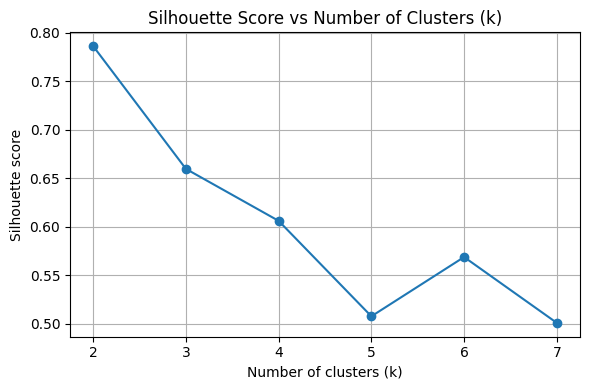

In [ ]:
#do not have the original trials anymore, so the values are hard coded just for reference

import matplotlib.pyplot as plt

ks = [2, 3, 4, 5, 6, 7]
silhouette_scores = [
    0.7862242401898488,
    0.6597162735453169,
    0.6061354137060083,
    0.507767858172977,
    0.5688462008268871,
    0.5009760676131045,
]

plt.figure(figsize=(6, 4))
plt.plot(ks, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xticks(ks)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# # Plot silhouette scores
# plt.figure(figsize=(6,4))
# plt.plot(range(2,10), silhouette_score, marker='o')
# plt.xlabel('k')
# plt.ylabel('Silhouette Score')
# plt.title('Silhouette Score vs k')
# plt.show()

# # Based on scores, we choose k=2 (local maximum)
best_k = 2


In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

kmeans = KMeans(featuresCol='features', k=best_k)
model = kmeans.fit(final_data)
predictions = model.transform(final_data)


In [ ]:
centers = model.clusterCenters()
print("\nCluster Centers:")
for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")

print("\nSample cluster predictions:")
predictions.select('prediction').show(5)


Cluster Centers:
Cluster 0: [-9.38389151e-02  5.75037906e+05  1.34694554e+06]
Cluster 1: [ 1.42710748e-01 -1.58250364e+06  2.31131697e+06]

Sample cluster predictions:
+----------+
|prediction|
+----------+
|         1|
|         1|
|         1|
|         1|
|         1|
+----------+
only showing top 5 rows



In [ ]:
predictions.show()

+----+-------------------+----------------+--------------------+--------------------+--------------------+----------+
| frp|         c_latitude|     c_longitude|             frp_vec|          scaled_frp|            features|prediction|
+----+-------------------+----------------+--------------------+--------------------+--------------------+----------+
| 3.1|-2350676.2428980106|2292255.42060716|[3.0999999046325684]|[-0.2187618739383...|[-0.2187618739383...|         1|
| 8.3|-2332301.2428980106|2284005.42060716| [8.300000190734863]|[-0.0687655886151...|[-0.0687655886151...|         1|
| 6.6|-2317676.2428980106|2205255.42060716| [6.599999904632568]|[-0.1178028412947...|[-0.1178028412947...|         1|
| 1.9|-2317301.2428980106|2283255.42060716| [1.899999976158142]|[-0.2533763973529...|[-0.2533763973529...|         1|
| 1.1|-2317301.2428980106|2203755.42060716| [1.100000023841858]|[-0.2764527462960...|[-0.2764527462960...|         1|
| 1.7|-2315801.2428980106|2197755.42060716|[1.7000000476

In [ ]:
from pyspark.ml.feature import PCA
import matplotlib.pyplot as plt

sampled_predictions = predictions.sample(
    withReplacement=False,
    fraction=0.0005,   # try 0.01; lower if still too big
    seed=42
)

pca = PCA(k=2, inputCol="features", outputCol="pcaFeatures")
pca_model = pca.fit(sampled_predictions)

pca_result = pca_model.transform(sampled_predictions).select("pcaFeatures", "prediction")

pandas_df = pca_result.toPandas()
pandas_df["x"] = pandas_df["pcaFeatures"].apply(lambda v: float(v[0]))
pandas_df["y"] = pandas_df["pcaFeatures"].apply(lambda v: float(v[1]))

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    pandas_df["x"],
    pandas_df["y"],
    c=pandas_df["prediction"],
    cmap="viridis",
    s=5
)
plt.title("K-Means Clusters (PCA 2D Projection, Sampled)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()


In [ ]:
import os
import findspark
findspark.init()
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MyFirstSparkApp") \
    .config("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true") \
    .config("spark.python.worker.faulthandler.enabled", "true") \
    .getOrCreate()

print("Spark version:", spark.version)


Spark version: 3.5.7


In [ ]:
csv_file_path = "data/features_array.csv"


df = spark.read.format("csv") \
    .option("header", "true") \
    .option("delimiter", "\t") \
    .option("inferSchema", "true") \
    .load(csv_file_path)

In [ ]:

df.show()

+----------+----------+-------+---------+---------+-------------+------------------+--------+--------+-----------+--------+---------+----------+---------+-------+-------+----------+-------+--------+---------+--------+-------+-------+----------+-------+--------+---------+---------+-------+-------+----------+-------+--------+---------+----------+-------+-------+----------+---------+--------+---------+---------+-------+-------+----------+-------+--------+---------+----------+-------+-------+----------+-------+--------+---------+----------+------+------+---------+--------+-------+--------+---------+------+------+---------+-------+-------+--------+---------+--------------------+-------------------+----------------+------------------+------------------+---------------------+------------------+-------------------+--------------------+-------------------+-----------------+-----------------+--------------------+-----------------+------------------+-------------------+------------------+--------

In [ ]:
from pyspark.sql.types import FloatType
from pyspark.sql.functions import col
filtered_df = df.filter(~col("frp").contains(","))
filtered_df = filtered_df.withColumn("frp", df["frp"].cast(FloatType()))
features_df = filtered_df.select("frp", "c_latitude","c_longitude")
features_df.show()

+----+-------------------+----------------+
| frp|         c_latitude|     c_longitude|
+----+-------------------+----------------+
| 3.1|-2350676.2428980106|2292255.42060716|
| 8.3|-2332301.2428980106|2284005.42060716|
| 6.6|-2317676.2428980106|2205255.42060716|
| 1.9|-2317301.2428980106|2283255.42060716|
| 1.1|-2317301.2428980106|2203755.42060716|
| 1.7|-2315801.2428980106|2197755.42060716|
| 1.6|-2315051.2428980106|2203005.42060716|
| 6.2|-2314676.2428980106|2129130.42060716|
| 2.9|-2314301.2428980106|2202630.42060716|
|16.3|-2313551.2428980106|2203755.42060716|
| 1.2|-2312801.2428980106|2201130.42060716|
| 1.6|-2311676.2428980106|2200380.42060716|
| 4.9|-2310176.2428980106|2120505.42060716|
| 0.7|-2308676.2428980106|2056755.42060716|
| 0.6|-2305676.2428980106|2181255.42060716|
| 1.8|-2304926.2428980106|2284380.42060716|
| 0.9|-2302301.2428980106|2251005.42060716|
|18.5|-2301551.2428980106|2141130.42060716|
| 2.9|-2301176.2428980106|2243130.42060716|
| 1.3|-2301176.2428980106|214188

In [ ]:
from pyspark.ml.feature import StandardScaler, VectorAssembler


frp_assembler = VectorAssembler(
    inputCols=["frp"],
    outputCol="frp_vec"
)
frp_vector = frp_assembler.transform(features_df)
scaler = StandardScaler(
    inputCol="frp_vec",
    outputCol="scaled_frp",
    withMean=True,
    withStd=True
)
scaled_model = scaler.fit(frp_vector)
scaled_data = scaled_model.transform(frp_vector)

scaled_data.show()

+----+-------------------+----------------+--------------------+--------------------+
| frp|         c_latitude|     c_longitude|             frp_vec|          scaled_frp|
+----+-------------------+----------------+--------------------+--------------------+
| 3.1|-2350676.2428980106|2292255.42060716|[3.0999999046325684]|[-0.2187618739383...|
| 8.3|-2332301.2428980106|2284005.42060716| [8.300000190734863]|[-0.0687655886151...|
| 6.6|-2317676.2428980106|2205255.42060716| [6.599999904632568]|[-0.1178028412947...|
| 1.9|-2317301.2428980106|2283255.42060716| [1.899999976158142]|[-0.2533763973529...|
| 1.1|-2317301.2428980106|2203755.42060716| [1.100000023841858]|[-0.2764527462960...|
| 1.7|-2315801.2428980106|2197755.42060716|[1.7000000476837158]|[-0.2591454828693...|
| 1.6|-2315051.2428980106|2203005.42060716| [1.600000023841858]|[-0.2620300273469...|
| 6.2|-2314676.2428980106|2129130.42060716| [6.199999809265137]|[-0.1293410192049...|
| 2.9|-2314301.2428980106|2202630.42060716|[2.90000009

In [ ]:
final_assembler = VectorAssembler(
    inputCols=["scaled_frp", "c_latitude", "c_longitude"],
    outputCol="features"
)

final_data = final_assembler.transform(scaled_data)

final_data.show()



+----+-------------------+----------------+--------------------+--------------------+--------------------+
| frp|         c_latitude|     c_longitude|             frp_vec|          scaled_frp|            features|
+----+-------------------+----------------+--------------------+--------------------+--------------------+
| 3.1|-2350676.2428980106|2292255.42060716|[3.0999999046325684]|[-0.2187618739383...|[-0.2187618739383...|
| 8.3|-2332301.2428980106|2284005.42060716| [8.300000190734863]|[-0.0687655886151...|[-0.0687655886151...|
| 6.6|-2317676.2428980106|2205255.42060716| [6.599999904632568]|[-0.1178028412947...|[-0.1178028412947...|
| 1.9|-2317301.2428980106|2283255.42060716| [1.899999976158142]|[-0.2533763973529...|[-0.2533763973529...|
| 1.1|-2317301.2428980106|2203755.42060716| [1.100000023841858]|[-0.2764527462960...|[-0.2764527462960...|
| 1.7|-2315801.2428980106|2197755.42060716|[1.7000000476837158]|[-0.2591454828693...|[-0.2591454828693...|
| 1.6|-2315051.2428980106|2203005.420

In [ ]:
# from pyspark.ml.clustering import KMeans
# from pyspark.ml.evaluation import ClusteringEvaluator
# import matplotlib.pyplot as plt

# silhouette_score = []

# evaluator = ClusteringEvaluator(predictionCol='prediction',
#                                 featuresCol='features', #nothing scaled for now
#                                 metricName='silhouette',
#                                 distanceMeasure='squaredEuclidean')

# for k in range(25, 29):
#     kmeans = KMeans(featuresCol='features', k=k)
#     model = kmeans.fit(final_data)
#     predictions = model.transform(final_data)
#     score = evaluator.evaluate(predictions)
#     silhouette_score.append(score)
#     print(f"Silhouette Score for k = {k} is {score}")

Silhouette Score for k = 7 is 0.5009760676131045


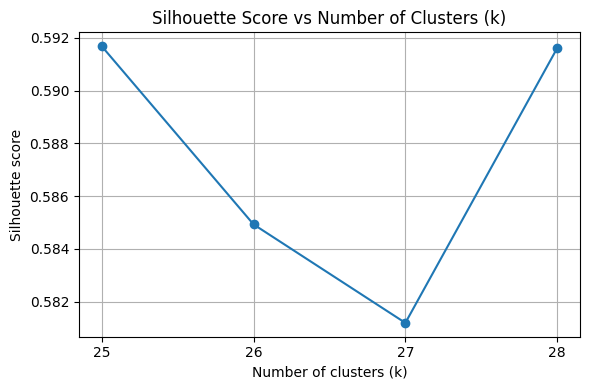

In [ ]:
import matplotlib.pyplot as plt
# Silhouette Score for k = 25 is 0.5916842447299505
# Silhouette Score for k = 26 is 0.5849323846163152
# Silhouette Score for k = 27 is 0.5812002324083021
# Silhouette Score for k = 28 is 0.5916115704555843
ks = [25, 26, 27, 28]
silhouette_scores = [
    0.5916842447299505,
    0.5849323846163152,
    0.5812002324083021,
    0.5916115704555843
]

plt.figure(figsize=(6, 4))
plt.plot(ks, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs Number of Clusters (k)")
plt.xticks(ks)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:

best_k = 25


In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

kmeans = KMeans(featuresCol='features', k=best_k)
model = kmeans.fit(final_data)
predictions = model.transform(final_data)


In [ ]:
centers = model.clusterCenters()
print("\nCluster Centers:")
for i, center in enumerate(centers):
    print(f"Cluster {i}: {center}")

# Show predictions for first few records
print("\nSample cluster predictions:")
predictions.select('prediction').show(5)


Cluster Centers:
Cluster 0: [ 1.68202670e-01 -1.96900181e+06  1.51304768e+06]
Cluster 1: [-1.92740705e-01  1.60703537e+06  2.02134269e+06]
Cluster 2: [-6.84906285e-02  4.15853540e+05  8.73321402e+05]
Cluster 3: [-6.38103343e-02  5.12266471e+05  1.46761641e+06]
Cluster 4: [ 2.06330696e-01 -8.04462021e+05  1.58780672e+06]
Cluster 5: [ 1.13191526e-01 -1.41527287e+06  2.75806280e+06]
Cluster 6: [-2.11273331e-01  6.69990868e+05  2.07554620e+06]
Cluster 7: [ 3.71479352e-01 -1.31206782e+06  2.11971614e+06]
Cluster 8: [ 8.12808134e-02 -1.82254386e+06  2.93770507e+06]
Cluster 9: [1.78233131e-02 1.39502658e+06 6.98456046e+05]
Cluster 10: [ 3.95316256e-02 -5.60908391e+04  1.60983298e+06]
Cluster 11: [ 1.32725501e-02 -6.68177373e+04  2.66768558e+06]
Cluster 12: [ 4.54803703e-02 -2.15901878e+06  2.42623812e+06]
Cluster 13: [-8.16962461e-02  9.69512370e+05  1.05372265e+06]
Cluster 14: [-1.43838544e-01 -1.12443380e+05  7.22814808e+05]
Cluster 15: [ 1.40014007e-01 -1.30621281e+06  1.29650220e+06]
Clu

In [ ]:
predictions.show()

+----+-------------------+----------------+--------------------+--------------------+--------------------+----------+
| frp|         c_latitude|     c_longitude|             frp_vec|          scaled_frp|            features|prediction|
+----+-------------------+----------------+--------------------+--------------------+--------------------+----------+
| 3.1|-2350676.2428980106|2292255.42060716|[3.0999999046325684]|[-0.2187618739383...|[-0.2187618739383...|        12|
| 8.3|-2332301.2428980106|2284005.42060716| [8.300000190734863]|[-0.0687655886151...|[-0.0687655886151...|        12|
| 6.6|-2317676.2428980106|2205255.42060716| [6.599999904632568]|[-0.1178028412947...|[-0.1178028412947...|        12|
| 1.9|-2317301.2428980106|2283255.42060716| [1.899999976158142]|[-0.2533763973529...|[-0.2533763973529...|        12|
| 1.1|-2317301.2428980106|2203755.42060716| [1.100000023841858]|[-0.2764527462960...|[-0.2764527462960...|        12|
| 1.7|-2315801.2428980106|2197755.42060716|[1.7000000476

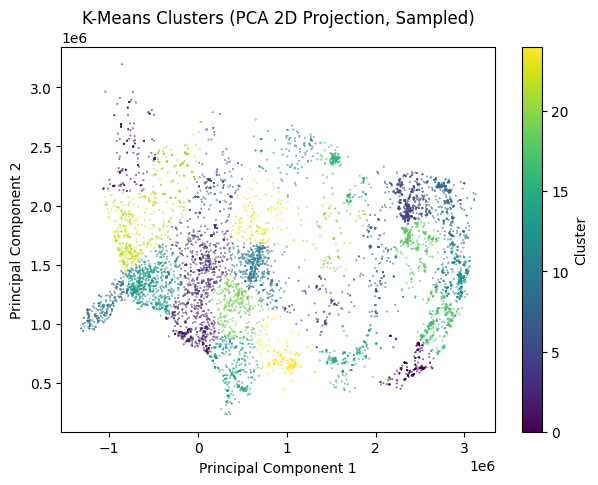

In [ ]:
from pyspark.ml.feature import PCA
import matplotlib.pyplot as plt


sampled_predictions = predictions.sample(
    withReplacement=False,
    fraction=0.0005,   # try 0.01; lower if still too big
    seed=42
)



pca = PCA(k=2, inputCol="features", outputCol="pcaFeatures")
pca_model = pca.fit(sampled_predictions)


pca_result = pca_model.transform(sampled_predictions).select("pcaFeatures", "prediction")


pandas_df = pca_result.toPandas()
pandas_df["x"] = pandas_df["pcaFeatures"].apply(lambda v: float(v[0]))
pandas_df["y"] = pandas_df["pcaFeatures"].apply(lambda v: float(v[1]))


plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    pandas_df["x"],
    pandas_df["y"],
    c=pandas_df["prediction"],
    cmap="viridis",
    s=0.1
)
plt.title("K-Means Clusters (PCA 2D Projection, Sampled)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()
